# Uncertainty

CLERO naturally produces a probability distribution over climates. `predict(..., return_variance=True)` returns the variance of each field at every grid cell. `sample(...)` returns samples from this climate distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from clero import Emulator
from clero.climate_analysis import global_mean, latitude_centers, latitude_weights

INPUTS = {
    "T_star": 3000.0, "F_star": 1000.0, "radius": 1.0, "gravity": 9.8,
    "P_rot": 10.0, "P0": 1.0, "CO2": 4.0e-4, "CH4": 0.0, "GCM": "um",
}
emu = Emulator()
lat = latitude_centers(emu.grid_shape[0])

## Uncertainty on derived quantities: examples

#### global-mean surface temperature. 

In [2]:
samples = emu.sample(INPUTS, n_samples=256, seed=0)
global_means = np.array([global_mean(s, lat) for s in samples["surface_temperature"]])
print(f"global-mean surface T: {global_means.mean():.2f} ± {global_means.std(ddof=1):.2f} K")

global-mean surface T: 242.15 ± 5.74 K


### maximum zonal-mean zonal wind over the five lowest levels.

In [12]:
# A wind diagnostic: the strongest zonal-mean zonal wind over the five lowest levels.
u_fields = [f"u_{i}" for i in range(10)]
wind_samples = emu.sample(INPUTS, fields=u_fields, n_samples=128, seed=1)
u_levels = np.stack([wind_samples[field] for field in u_fields], axis=1)  # (sample, level, lat, lon)
max_zonal_mean_zonal_wind = np.abs(u_levels[:, :5].mean(axis=-1)).max(axis=(1, 2))
print(
    "max zonal-mean zonal wind: "
    f"{max_zonal_mean_zonal_wind.mean():.2f} ± {max_zonal_mean_zonal_wind.std(ddof=1):.2f} m/s"
)


max zonal-mean zonal wind: 33.00 ± 2.99 m/s


## Per-cell uncertainty: analytic variance versus samples

`predict(..., return_variance=True)` returns the variance of each field at every grid cell, with no sampling. Here we check that samples give the same answer. For each instellation we compute the per-cell standard deviation of surface temperature twice, once from the analytic variance and once from 64 samples, and average each over the map. The two curves agree to within sampling noise.

Both curves are per-cell quantities. Neither is the uncertainty on the global mean; that is the subject of the next section.

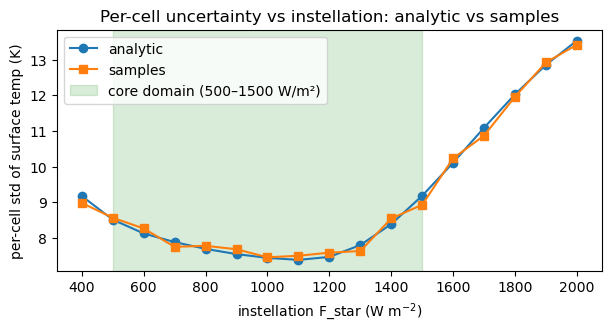

In [4]:
# Per-cell std of surface temperature vs instellation: analytic variance vs samples, averaged over the map.
fluxes = np.arange(400.0, 2000.0 + 1.0, 100.0)  # inside the extended domain (400–3100 W/m²)
flux_batch = [{**INPUTS, "F_star": float(f_star)} for f_star in fluxes]
w = latitude_weights(lat)

_, variance = emu.predict(flux_batch, fields=["surface_temperature"], space="model", return_variance=True)
analytic_std = (np.sqrt(variance["surface_temperature"]).mean(axis=2) * w[None]).sum(axis=1)

surface_samples = emu.sample(flux_batch, fields=["surface_temperature"], n_samples=1024, seed=2, space="model", batch_size=1)["surface_temperature"]
sample_std = (surface_samples.std(axis=0, ddof=1).mean(axis=2) * w[None]).sum(axis=1)

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.plot(fluxes, analytic_std, marker="o", label="analytic")
ax.plot(fluxes, sample_std, marker="s", label="samples")
ax.axvspan(500.0, 1500.0, alpha=0.15, color="green", label="core domain (500–1500 W/m²)")
ax.set(
    xlabel="instellation F_star (W m$^{-2}$)",
    ylabel="per-cell std of surface temp (K)",
    title="Per-cell uncertainty vs instellation: analytic vs samples",
)
ax.legend()
plt.show()


## Uncertainty on the global mean

We can't get the uncertainty on the global mean from the per-cell variance alone, because errors in different cells are correlated. But we can get it easily from samples! (We could also calculate it analytically using CLERO's predictive covariance matrix).

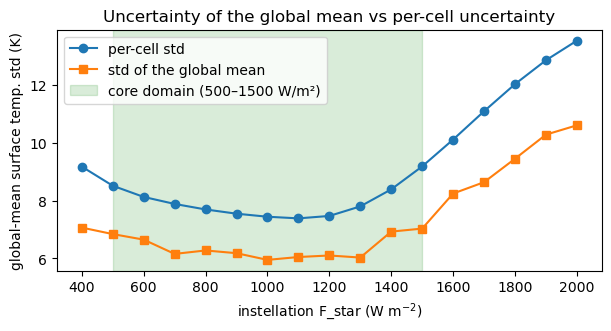

In [5]:
# Std of the global-mean surface temperature across samples. Surface temperature is not transformed,
# so model space and physical units coincide and the model-space samples above can be reused.
global_means = np.array([[global_mean(s, lat) for s in per_flux] for per_flux in surface_samples.swapaxes(0, 1)])  # (flux, sample)
scalar_std = global_means.std(axis=1, ddof=1)

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.plot(fluxes, analytic_std, marker="o", label="per-cell std")
ax.plot(fluxes, scalar_std, marker="s", label="std of the global mean")
ax.axvspan(500.0, 1500.0, alpha=0.15, color="green", label="core domain (500–1500 W/m²)")
ax.set(
    xlabel="instellation F_star (W m$^{-2}$)",
    ylabel="global-mean surface temp. std (K)",
    title="Uncertainty of the global mean vs per-cell uncertainty",
)
ax.legend()
plt.show()


## Global-mean surface temperature with uncertainty bands

The median of the per-sample global means is the central estimate, and quantiles give the bands: the 16th to 84th percentiles for roughly 1σ and the 2.5th to 97.5th for roughly 2σ.

The bands widen outside the core domain (500–1500 W/m² for instellation), where there are fewer training simulations. The same happens for every input; see [SCOPE.md](../SCOPE.md) for the core and extended domains.

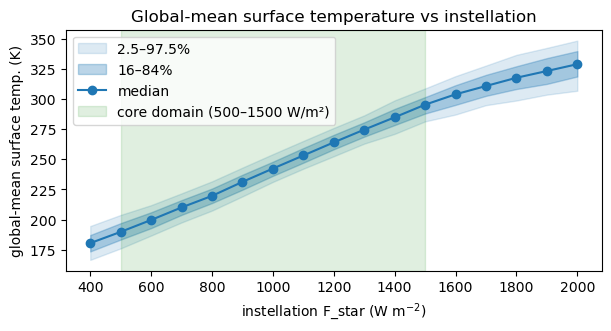

In [6]:
# Quantiles of the per-sample global means (flux, sample) across the sample axis.
lo2, lo1, med, hi1, hi2 = np.quantile(global_means, [0.025, 0.16, 0.5, 0.84, 0.975], axis=1)

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.fill_between(fluxes, lo2, hi2, alpha=0.15, color="C0", label="2.5–97.5%")
ax.fill_between(fluxes, lo1, hi1, alpha=0.30, color="C0", label="16–84%")
ax.plot(fluxes, med, color="C0", marker="o", label="median")
ax.axvspan(500.0, 1500.0, alpha=0.12, color="green", label="core domain (500–1500 W/m²)")
ax.set(
    xlabel="instellation F_star (W m$^{-2}$)",
    ylabel="global-mean surface temp. (K)",
    title="Global-mean surface temperature vs instellation",
)
ax.legend()
plt.show() 
